# Лекция 2. Очистка и подготовка данных: недвижимость

В этом ноутбуке разберём полный путь первичного анализа и очистки датасета с объявлениями о недвижимости.

Основная идея занятия: сначала понять, что лежит в таблице, затем явно найти проблемы, показать их на графиках, аккуратно обработать пропуски, дубликаты, выбросы и категориальные признаки.

Мы будем работать с файлом `data.csv`.


## Оглавление

1. [Цель и план работы](#goal)
2. [Импорт библиотек и настройки](#libraries)
3. [Загрузка данных](#load)
4. [Первичный осмотр датасета](#first-look)
5. [Описание важных полей](#fields)
6. [Пропуски: таблицы и графики](#missing)
7. [Дубликаты](#duplicates)
8. [Синтетические проблемы и выбросы](#synthetic)
9. [Преобразование типов](#types)
10. [Обработка отдельных признаков](#features)
11. [Удаление лишних признаков](#drop-columns)
12. [Итоговая обработка пропусков](#final-missing)
13. [Кодирование категориальных признаков](#encoding)
14. [Корреляции](#correlations)
15. [Сравнение грязного и чистого датасета](#compare)
16. [Итог](#summary)


<a id="goal"></a>
## 1. Цель и план работы

Перед машинным обучением или серьёзным анализом таблицу почти всегда нужно подготовить.

В этом ноутбуке мы:

- загрузим грязный датасет;
- посмотрим размер, типы данных и первые строки;
- найдём пропуски и покажем их на графиках;
- проверим дубликаты;
- найдём искусственно добавленные выбросы через `synthetic_issue` и `original_price` (я добавила для наглядности, в работе такое встречается нередко);
- приведём признаки к подходящим типам;
- обработаем признаки по смыслу;
- удалим лишние поля;
- закодируем категориальные признаки;
- посмотрим корреляции;

<a id="libraries"></a>
## 2. Импорт библиотек и настройки

Используем стандартный набор для табличного анализа:

- `pandas` для работы с таблицами;
- `numpy` для числовых операций;
- `matplotlib` и `seaborn` для графиков;
- `re` для регулярных выражений, которые помогут извлечь улицу из адреса;
- `warnings` для скрытия технических предупреждений, которые мешают читать ноутбук.

In [50]:
# re нужен для поиска улицы внутри текстового адреса
import re

# warnings нужен, чтобы скрыть технические предупреждения библиотек
import warnings

# numpy нужен для числовых операций и np.nan
import numpy as np

# pandas нужен для работы с таблицами dataframe
import pandas as pd

# matplotlib нужен для базовых графиков
import matplotlib.pyplot as plt

# seaborn нужен для более красивых статистических графиков
import seaborn as sns

# скрываем предупреждения, чтобы они не перегружали учебный ноутбук
warnings.filterwarnings("ignore")

# показываем графики прямо внутри ноутбука
%matplotlib inline

# задаем общий стиль графиков
sns.set_theme(style="whitegrid", palette="colorblind")
# показываем до 80 колонок dataframe
pd.set_option("display.max_columns", 80)
# показываем до 120 строк при выводе таблиц
pd.set_option("display.max_rows", 120)
# выводим числа с двумя знаками после запятой
pd.set_option("display.float_format", "{:.2f}".format)

<a id="load"></a>
## 3. Загрузка данных

Загружаем исходную таблицу. Сразу сделаем две копии:

- `df_raw` исходный датасет, который не будем менять;
- `df` рабочая копия, которую будем чистить.


In [56]:
# указываем файл с данными
DATA_PATH = "data.csv"

# загружаем исходную таблицу
df_raw = pd.read_csv(DATA_PATH)

# делаем рабочую копию, которую будем менять
# исходный df_raw оставляем для сравнения в конце
df = df_raw.copy()

print("Размер исходного датасета:", df_raw.shape)
print("Размер рабочей копии:", df.shape)
df.drop(['synthetic_issue', 'original_price'], axis=1).head()

Размер исходного датасета: (8132, 22)
Размер рабочей копии: (8132, 22)


,id,Тип рынка,Новостройка,Категория объекта,Всего этажей в доме,city,Тип дома,Общая площадь,Этаж,price,Описание,Категория комнатности,Парковка,Балкон или лоджия,Спортивная площадка,Пассажирский лифт,street,address_raw,Ремонт,Мебель
0,0,Новостройка,Новостройка,Квартиры,16,Махачкала,монолитно-кирпичный,80.00,10,5198000,ОБЪЯBЛEHИЯ «TУРАЛИ» 📍 ЖK Турали — лучший выбоp...,2-комнатные,открытая во дворе,NaN,1.00,1.00,ул. Металлургов,"Республика Дагестан, Махачкала, ул. Металлурго...",NaN,NaN
1,1,Новостройка,Новостройка,Квартиры,8,Каспийск,монолитно-кирпичный,59.00,7,3540000,🅰️ | ЖК «AЛЫE ПАPУСA» - ПОЛНЫЙ ПАКЕT ДОKУМEHТО...,2-комнатные,"открытая во дворе, за шлагбаумом во дворе","балкон, лоджия",1.00,1.00,NaN,"Республика Дагестан, Карабудахкентский р-н, Ту...",NaN,NaN
2,2,Новостройка,Новостройка,Квартиры,8,Кизляр,монолитный,34.00,8,2040000,🫴Строитeльная кoмпания предлагает -- нoвый жил...,Студии,"наземная многоуровневая, открытая во дворе, за...",NaN,1.00,1.00,ул. Гамидова,"Республика Дагестан, Кизляр, ул. Гамидова, 29",NaN,NaN
3,3,Вторичка,Вторичка,Квартиры,14,Каспийск,монолитно-кирпичный,91.20,3,9099999,🏢 Пpeдcтавляю Вaшeму внимaнию квартиру с пpекp...,3-комнатные,"открытая во дворе, за шлагбаумом во дворе",NaN,1.00,1.00,пр-т Акулиничева,"Республика Дагестан, Каспийск, пр-т Акулиничев...",требует ремонта,NaN
4,4,Вторичка,Вторичка,Квартиры,6,Дербент,монолитно-кирпичный,46.00,4,5250000,Пpoдoётся 1к. кв. на 4/6 дoмa.Центр городa. Св...,1-комнатные,открытая во дворе,балкон,NaN,0.00,Приморская ул.,"Республика Дагестан, Дербент, Приморская ул., 1Л",косметический,NaN


<a id="first-look"></a>
## 4. Первичный осмотр датасета

Первичный осмотр помогает понять:

- сколько строк и столбцов в таблице;
- какие есть типы данных;
- есть ли очевидные текстовые, числовые и категориальные признаки;
- какие признаки выглядят служебными и не должны попадать в итоговую модель.

### Что показывает `describe()`

Метод `describe()` быстро считает основные статистики по числовым столбцам.

- `count` показывает, сколько непустых значений есть в столбце.
- `mean` показывает среднее значение.
- `std` показывает разброс значений вокруг среднего. Большое std означает, что значения сильно различаются, поэтому среднее хуже описывает отдельный объект или человека.
- `min` показывает минимальное значение.
- `25%` показывает первый квартиль. 25% значений меньше или равны этому числу.
- `50%` показывает медиану. 50% значений меньше или равны этому числу.
- `75%` показывает третий квартиль. 75% значений меньше или равны этому числу.
- `max` показывает максимальное значение.

Среднее не всегда честно описывает типичное значение, если есть сильные выбросы.

Например, зарплаты в группе: `30, 35, 45, 38, 40, 37, 250` тысяч рублей.

Если считать среднее, зарплата `250` сильно потянет результат вверх. Получится ощущение, что типичная зарплата в группе выше, чем на самом деле. В такой ситуации медиана честнее: она показывает значение ближе к центру обычных зарплат группы и меньше зависит от одного очень большого значения.

В недвижимости это особенно важно. Одна очень дорогая квартира может сильно увеличить среднюю цену, поэтому рядом со средним всегда полезно смотреть медиану и квартили `25%`, `50%`, `75%`.

In [60]:
np.mean([30, 35, 45, 38, 40, 37, 250])

np.float64(67.85714285714286)

In [61]:
np.mean([30, 35, 45, 38, 40, 37])

np.float64(37.5)

In [ ]:
np.median([30, 35, 45, 38, 40, 37, 250])

# 30 35 37 38 40 45 250
# 1. 2. 3. 4. 5. 6. 7. 

np.float64(38.0)

In [3]:
# смотрим типы столбцов и количество непустых значений
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8132 entries, 0 to 8131
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     8132 non-null   int64  
 1   synthetic_issue        8132 non-null   str    
 2   original_price         8132 non-null   int64  
 3   Тип рынка              8132 non-null   str    
 4   Новостройка            8132 non-null   str    
 5   Категория объекта      8132 non-null   str    
 6   Всего этажей в доме    8132 non-null   int64  
 7   city                   8132 non-null   str    
 8   Тип дома               8132 non-null   str    
 9   Общая площадь          8132 non-null   float64
 10  Этаж                   8132 non-null   int64  
 11  price                  8132 non-null   int64  
 12  Описание               8132 non-null   str    
 13  Категория комнатности  7959 non-null   str    
 14  Парковка               7219 non-null   str    
 15  Балкон или лодж

In [4]:
# смотрим статистики только по числовым признакам
df.drop(['original_price'], axis=1).describe()

,id,Всего этажей в доме,Общая площадь,Этаж,price,Спортивная площадка,Пассажирский лифт
count,8132.00,8132.00,8132.00,8132.00,8132.00,5464.00,6771.00
mean,4065.50,9.28,59.93,5.14,9087234.19,1.00,0.85
std,2347.65,3.43,77.22,2.91,135686318.04,0.00,0.45
min,0.00,1.00,17.00,1.00,3.00,1.00,0.00
25%,2032.75,8.00,40.00,3.00,3000000.00,1.00,1.00
50%,4065.50,8.00,54.00,5.00,4440000.00,1.00,1.00
75%,6098.25,12.00,70.00,7.00,6550000.00,1.00,1.00
max,8131.00,86.00,4500.00,18.00,5000000000.00,1.00,4.00


In [5]:
# смотрим статистики по всем типам столбцов
# include="all" добавляет текстовые признаки, .t переворачивает таблицу
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,8132.00,NaN,NaN,NaN,4065.50,2347.65,0.00,2032.75,4065.50,6098.25,8131.00
synthetic_issue,8132,5,original,7888,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_price,8132.00,NaN,NaN,NaN,5392396.16,3677653.08,3462.00,3146250.00,4440000.00,6620475.00,67000000.00
Тип рынка,8132,2,Новостройка,5210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Новостройка,8132,2,Новостройка,5210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Категория объекта,8132,1,Квартиры,8132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Всего этажей в доме,8132.00,NaN,NaN,NaN,9.28,3.43,1.00,8.00,8.00,12.00,86.00
city,8132,6,Каспийск,2129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Тип дома,8132,6,монолитно-кирпичный,4729,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Общая площадь,8132.00,NaN,NaN,NaN,59.93,77.22,17.00,40.00,54.00,70.00,4500.00


In [65]:
df.isna().sum().values
# isNAn

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,  173,  913, 3230, 2668, 1361, 1819,    7, 5210, 6668])

In [68]:
df['Тип рынка'].value_counts()

Тип рынка
Новостройка    5210
Вторичка       2922
Name: count, dtype: int64

In [69]:
df['Тип рынка'].unique()

<StringArray>
['Новостройка', 'Вторичка']
Length: 2, dtype: str

In [70]:
df['Тип рынка'].nunique()

2

In [6]:
pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean() * 100).round(2).values,
    "n_unique": df.nunique(dropna=False).values,
}).sort_values("missing_percent", ascending=False)


,column,dtype,missing_count,missing_percent,n_unique
21,Мебель,str,6668,82.00,8
20,Ремонт,str,5210,64.07,5
15,Балкон или лоджия,str,3230,39.72,4
16,Спортивная площадка,float64,2668,32.81,2
18,street,str,1819,22.37,450
17,Пассажирский лифт,float64,1361,16.74,5
14,Парковка,str,913,11.23,31
13,Категория комнатности,str,173,2.13,10
19,address_raw,str,7,0.09,1906
1,synthetic_issue,str,0,0.00,5


<a id="fields"></a>
## 5. Описание важных полей

Забегая вперед, вот наш подробный план:

- `synthetic_issue`, `original_price` служебные поля. Они нужны только для проверки искусственно добавленных проблем. После проверки удалим строки с синтетическими проблемами и сами эти поля.
- `Тип рынка`, `Новостройка` дублируют друг друга. Оставим один признак.
- `Категория объекта` константный признак: везде одно значение. Он не помогает анализу.
- `Всего этажей в доме`, `Этаж`, `Общая площадь`, `price` числовые признаки.
- `price_per_m2_calc` новый признак, который рассчитаем сами из `price` и `Общая площадь`.
- `Описание` пример текстовых данных. В этом занятии не будем превращать текст в признаки.
- `Категория комнатности` категориальный признак, который можно превратить в число комнат.
- `Парковка`, `Балкон или лоджия`, `Спортивная площадка` если значение указано, ставим `1`, если не указано, ставим `0`.
- `Пассажирский лифт` если значение указано, используем число лифтов. Если пропуск, это неизвестное значение, поэтому отдельно закодируем его как `-1`.
- `street`, `address_raw` попробуем заполнить улицу из сырого адреса.
- `Ремонт`, `Мебель` удалим, потому что там много пропусков и надёжно восстановить значения нельзя.

In [71]:
# выбираем важные признаки для первого просмотра
important_cols = [
    "synthetic_issue", "original_price",
    "Тип рынка", "Новостройка", "Категория объекта",
    "Всего этажей в доме", "city", "Тип дома",
    "Общая площадь", "Этаж", "price",
    "Описание", "Категория комнатности",
    "Парковка", "Балкон или лоджия", "Спортивная площадка",
    "Пассажирский лифт",
    "street", "address_raw",
    "Ремонт", "Мебель",
]

df[important_cols].head()

,synthetic_issue,original_price,Тип рынка,Новостройка,Категория объекта,Всего этажей в доме,city,Тип дома,Общая площадь,Этаж,price,Описание,Категория комнатности,Парковка,Балкон или лоджия,Спортивная площадка,Пассажирский лифт,street,address_raw,Ремонт,Мебель
0,original,5198000,Новостройка,Новостройка,Квартиры,16,Махачкала,монолитно-кирпичный,80.00,10,5198000,ОБЪЯBЛEHИЯ «TУРАЛИ» 📍 ЖK Турали — лучший выбоp...,2-комнатные,открытая во дворе,NaN,1.00,1.00,ул. Металлургов,"Республика Дагестан, Махачкала, ул. Металлурго...",NaN,NaN
1,original,3540000,Новостройка,Новостройка,Квартиры,8,Каспийск,монолитно-кирпичный,59.00,7,3540000,🅰️ | ЖК «AЛЫE ПАPУСA» - ПОЛНЫЙ ПАКЕT ДОKУМEHТО...,2-комнатные,"открытая во дворе, за шлагбаумом во дворе","балкон, лоджия",1.00,1.00,NaN,"Республика Дагестан, Карабудахкентский р-н, Ту...",NaN,NaN
2,original,2040000,Новостройка,Новостройка,Квартиры,8,Кизляр,монолитный,34.00,8,2040000,🫴Строитeльная кoмпания предлагает -- нoвый жил...,Студии,"наземная многоуровневая, открытая во дворе, за...",NaN,1.00,1.00,ул. Гамидова,"Республика Дагестан, Кизляр, ул. Гамидова, 29",NaN,NaN
3,original,9099999,Вторичка,Вторичка,Квартиры,14,Каспийск,монолитно-кирпичный,91.20,3,9099999,🏢 Пpeдcтавляю Вaшeму внимaнию квартиру с пpекp...,3-комнатные,"открытая во дворе, за шлагбаумом во дворе",NaN,1.00,1.00,пр-т Акулиничева,"Республика Дагестан, Каспийск, пр-т Акулиничев...",требует ремонта,NaN
4,original,5250000,Вторичка,Вторичка,Квартиры,6,Дербент,монолитно-кирпичный,46.00,4,5250000,Пpoдoётся 1к. кв. на 4/6 дoмa.Центр городa. Св...,1-комнатные,открытая во дворе,балкон,NaN,0.00,Приморская ул.,"Республика Дагестан, Дербент, Приморская ул., 1Л",косметический,NaN


<a id="missing"></a>
## 6. Пропуски: таблицы и графики

Пропуск это пустое значение в таблице. В pandas пропуски обычно обозначаются как `NaN`.

Базовая команда:

```python
df.isna().sum()
```

Она считает количество пропусков в каждом столбце.


In [72]:
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100,
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(dropna=False),
}).sort_values("missing_count", ascending=False)

missing_table.head(30)


,missing_count,missing_percent,dtype,n_unique
Мебель,6668,82.00,str,8
Ремонт,5210,64.07,str,5
Балкон или лоджия,3230,39.72,str,4
Спортивная площадка,2668,32.81,float64,2
street,1819,22.37,str,450
Пассажирский лифт,1361,16.74,float64,5
Парковка,913,11.23,str,31
Категория комнатности,173,2.13,str,10
address_raw,7,0.09,str,1906
synthetic_issue,0,0.00,str,5


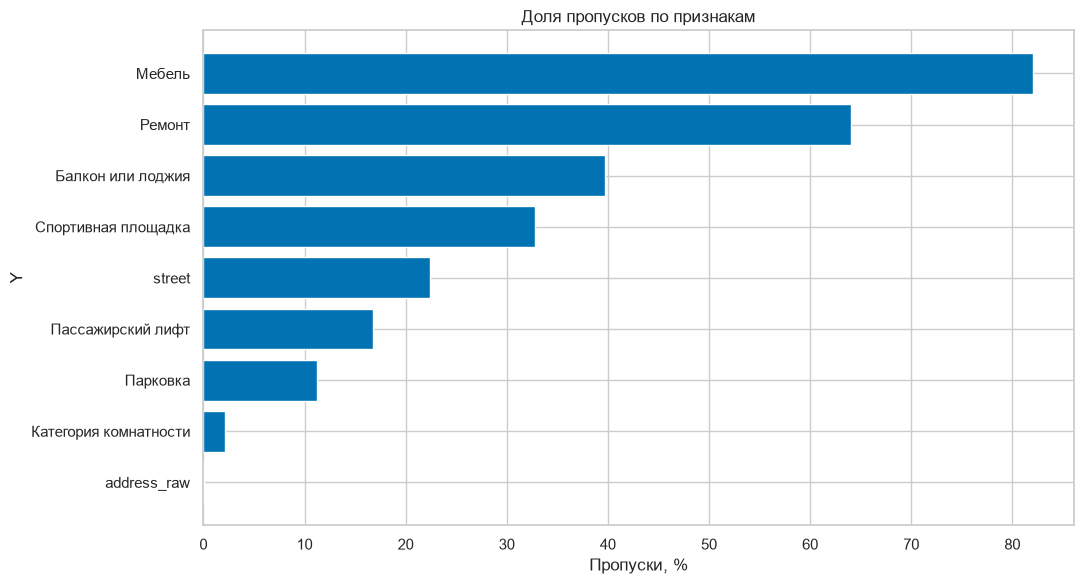

In [74]:
missing_nonzero = missing_table[missing_table["missing_count"] > 0].sort_values("missing_percent")

plt.figure(figsize=(11, max(6, 0.35 * len(missing_nonzero))))
plt.barh(missing_nonzero.index, missing_nonzero["missing_percent"])
plt.title("Доля пропусков по признакам")
plt.xlabel("Пропуски, %")
plt.ylabel("Y")
plt.tight_layout()
plt.show()


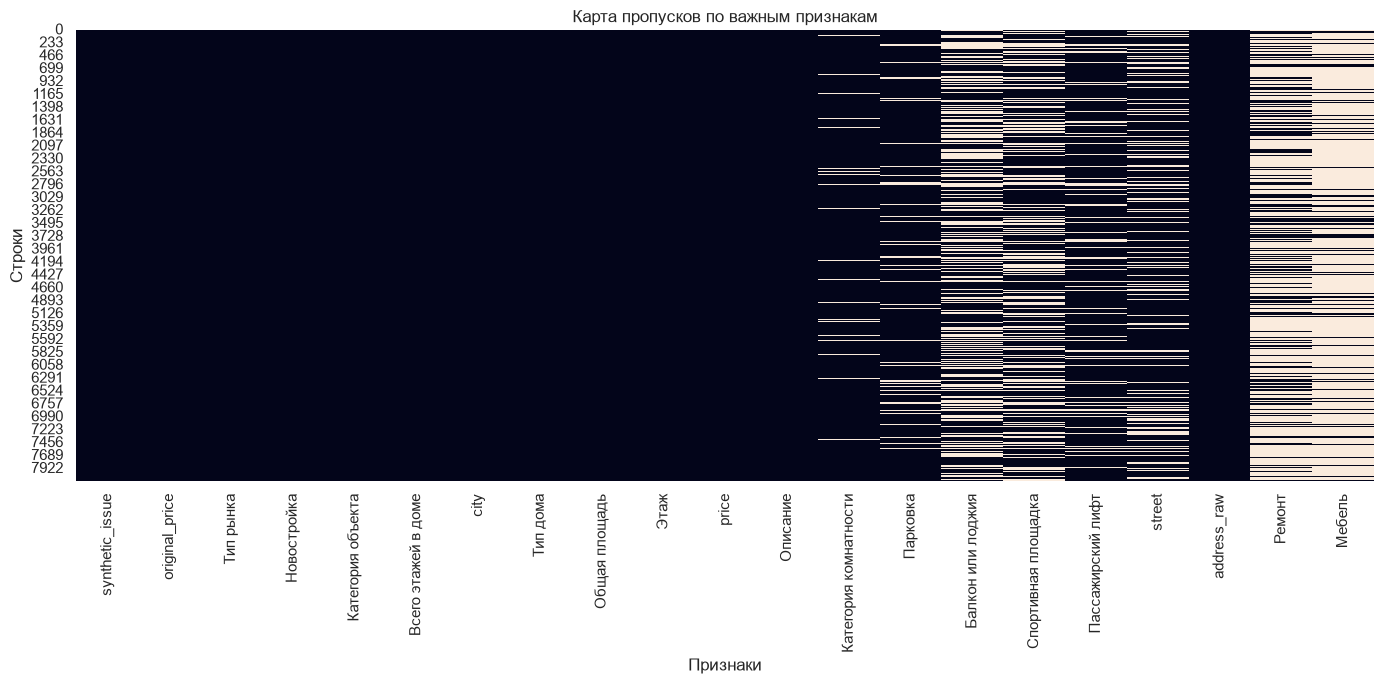

In [75]:
plt.figure(figsize=(14, 7))
sns.heatmap(df[important_cols].isna(), cbar=False)
plt.title("Карта пропусков по важным признакам")
plt.xlabel("Признаки")
plt.ylabel("Строки")
plt.tight_layout()
plt.show()


Карта пропусков читается так:

- тёмные и светлые участки показывают, где значения есть, а где их нет;
- если у признака почти вся колонка одного цвета, значит пропусков либо почти нет, либо очень много;
- если пропуски идут блоками, это может означать, что часть данных пришла из другого источника или была собрана по другой логике.


<a id="duplicates"></a>
## 7. Дубликаты

Дубликаты это повторяющиеся строки или повторяющиеся объекты. В объявлениях о недвижимости одна и та же квартира может попасть в датасет несколько раз.

Проверим:

- полные дубликаты строк;
- дубликаты по идентификатору `id`;


In [76]:
print("Полные дубликаты строк:", df.duplicated().sum())
print("Дубликаты по id:", df.duplicated(subset=["id"]).sum())

Полные дубликаты строк: 0
Дубликаты по id: 0


In [12]:
duplicate_examples = df[df.duplicated(subset=["id"], keep=False)].sort_values("id")
duplicate_examples.head(10)

,id,synthetic_issue,original_price,Тип рынка,Новостройка,Категория объекта,Всего этажей в доме,city,Тип дома,Общая площадь,Этаж,price,Описание,Категория комнатности,Парковка,Балкон или лоджия,Спортивная площадка,Пассажирский лифт,street,address_raw,Ремонт,Мебель


Для очистки оставим первое объявление по каждому `id`.  
Если в задаче важна история изменения цены, тогда дубликаты нужно анализировать отдельно. В нашем учебном примере цель получить одну строку на один объект.


In [13]:
rows_before = len(df)
df = df.drop_duplicates(subset=["id"], keep="first").copy()
rows_after = len(df)

print("Строк до удаления дубликатов:", rows_before)
print("Строк после удаления дубликатов:", rows_after)
print("Удалено строк:", rows_before - rows_after)


Строк до удаления дубликатов: 8132
Строк после удаления дубликатов: 8132
Удалено строк: 0


<a id="synthetic"></a>
## 8. Синтетические проблемы и выбросы

Поля `synthetic_issue` и `original_price` были добавлены искусственно:

- `synthetic_issue` показывает, какая проблема была сгенерирована;
- `original_price` хранит исходную цену до синтетического искажения.

Сначала явно проверим эти поля, затем покажем выбросы на boxplot. После этого удалим строки, где `synthetic_issue != "original"`, и удалим сами служебные поля.

### Как читать boxplot

Boxplot показывает распределение признака компактно.

- линия внутри коробки это медиана;
- нижняя граница коробки это `25%`, первый квартиль;
- верхняя граница коробки это `75%`, третий квартиль;
- сама коробка показывает центральные 50% значений;
- точки за пределами усов это возможные выбросы.

Границы усов боксплота:
- нижняя: Q1 − 1.5 × IQR;
- верхняя: Q3 + 1.5 × IQR.

Если на boxplot есть точки очень далеко от основной коробки, значит в данных есть необычно большие или маленькие значения. В нашем случае такие точки помогают увидеть искусственно созданные проблемы с ценой.

![Как читать боксплот](boxplot_explained.png)

Межквартильный размах:

$$
IQR = Q_3 - Q_1
$$

где:

- $IQR$ — межквартильный размах;
- $Q_1$ — первый квартиль (25-й процентиль);
- $Q_3$ — третий квартиль (75-й процентиль).

Стандартное отклонение:

$$
\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(x_i - \mu)^2}
$$

где:

- $\sigma$ — стандартное отклонение;
- $N$ — количество значений в выборке;
- $x_i$ — отдельное значение;
- $\mu$ — среднее арифметическое всех значений;
- $(x_i - \mu)$ — отклонение каждого значения от среднего;
- $(x_i - \mu)^2$ — квадрат этого отклонения;
- $\sum_{i=1}^{N}$ — сумма квадратов отклонений для всех значений.

In [77]:
# df["synthetic_issue"].value_counts(dropna=False)


In [78]:
# # смотрим строки, где цена была синтетически изменена
# synthetic_cols = ["id", "synthetic_issue", "price", "original_price", "Общая площадь"]

# synthetic_check = df.loc[df["synthetic_issue"] != "original", synthetic_cols]
# synthetic_check.head(15)

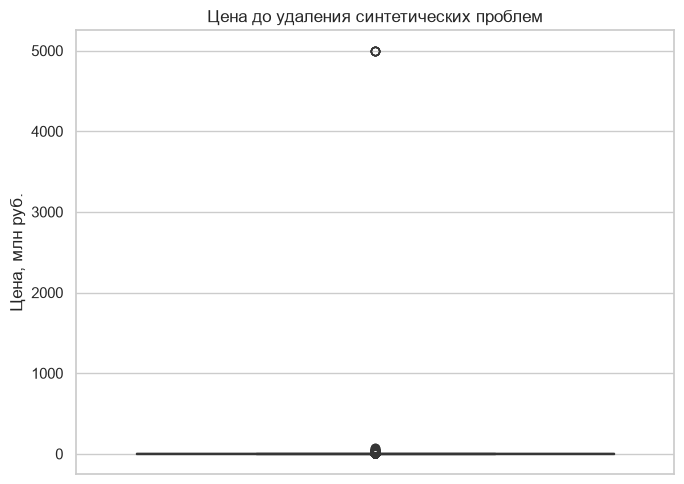

In [79]:
# нужно для более удобного формата
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(data=df, y="price", ax=ax)
ax.set_title("Цена до удаления синтетических проблем")
ax.set_ylabel("Цена, млн руб.")

# показываем значения оси в миллионах
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value / 1_000_000:g}")
)

plt.tight_layout()
plt.show()

In [82]:
df.columns

Index(['id', 'synthetic_issue', 'original_price', 'Тип рынка', 'Новостройка',
       'Категория объекта', 'Всего этажей в доме', 'city', 'Тип дома',
       'Общая площадь', 'Этаж', 'price', 'Описание', 'Категория комнатности',
       'Парковка', 'Балкон или лоджия', 'Спортивная площадка',
       'Пассажирский лифт', 'street', 'address_raw', 'Ремонт', 'Мебель'],
      dtype='str')

In [83]:
df[df['Всего этажей в доме']>=80]

,id,synthetic_issue,original_price,Тип рынка,Новостройка,Категория объекта,Всего этажей в доме,city,Тип дома,Общая площадь,Этаж,price,Описание,Категория комнатности,Парковка,Балкон или лоджия,Спортивная площадка,Пассажирский лифт,street,address_raw,Ремонт,Мебель
2221,2221,original,1960000,Новостройка,Новостройка,Квартиры,86,Избербаш,монолитно-кирпичный,28.00,7,1960000,Прoдаются квартиpы в ЖК «ЛЕРМОHТOВА» — успейтe...,Студии,открытая во дворе,лоджия,1.00,2.00,ул. Лермонтова,"Республика Дагестан, Избербаш, ул. Лермонтова, 12",NaN,NaN


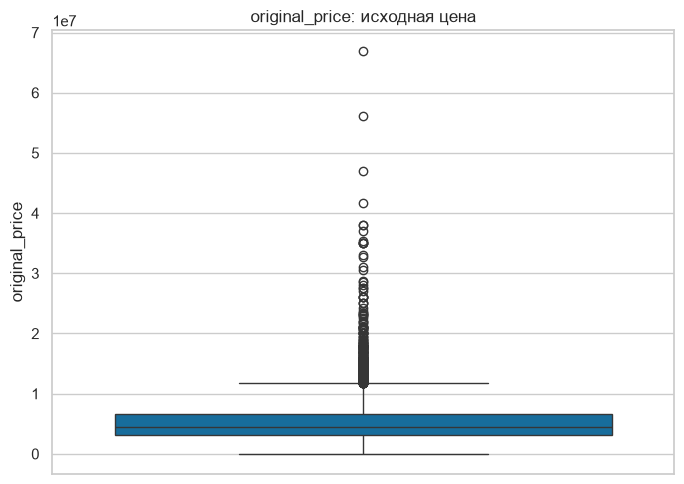

In [80]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(data=df, y="original_price", ax=ax)
ax.set_title("original_price: исходная цена")
ax.set_ylabel("original_price")

plt.tight_layout()
plt.show()

На графиках видно, что искусственно добавленные строки сильно искажают распределение цены.  
Это не настоящие наблюдения, поэтому удаляем их.


In [84]:
rows_before = len(df)
df = df[df["synthetic_issue"] == "original"].copy()
rows_after = len(df)

print("Строк до удаления synthetic_issue:", rows_before)
print("Строк после удаления synthetic_issue:", rows_after)
print("Удалено строк:", rows_before - rows_after)


Строк до удаления synthetic_issue: 8132
Строк после удаления synthetic_issue: 7888
Удалено строк: 244


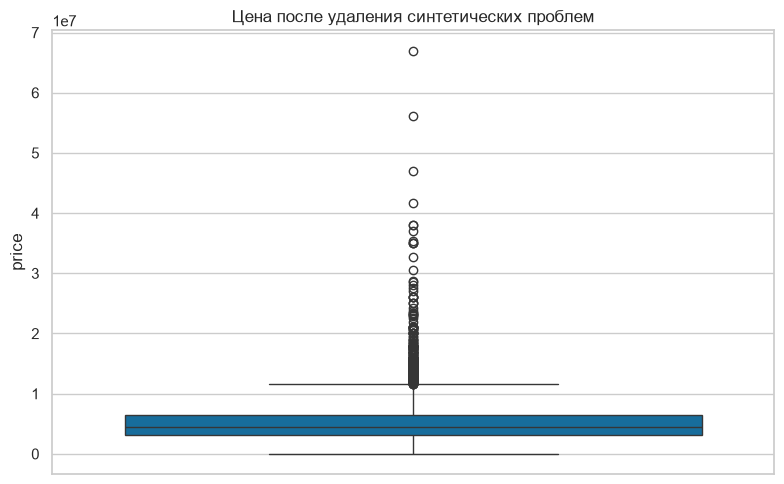

In [88]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="price")
plt.title("Цена после удаления синтетических проблем")
plt.ylabel("price")
plt.tight_layout()
plt.show()


<a id="types"></a>
## 9. Преобразование типов

Числовые признаки должны быть числовыми, а категориальные строковыми или категориальными.  
Если число хранится как текст, pandas не сможет корректно считать среднее, медиану или корреляцию.


In [89]:
# приводим числовые признаки к числовому типу
numeric_cols = [
    "price", "original_price",
    "Общая площадь", "Этаж", "Всего этажей в доме",
    "Пассажирский лифт",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# приводим текстовые признаки к строковому типу
text_cols = [
    "city", "Тип дома", "Тип рынка", "Новостройка", "Категория объекта",
    "Описание", "Парковка", "Балкон или лоджия", "street",
    "address_raw", "Ремонт", "Мебель",
]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype("string")

df[numeric_cols].dtypes

price                    int64
original_price           int64
Общая площадь          float64
Этаж                     int64
Всего этажей в доме      int64
Пассажирский лифт      float64
dtype: object

In [90]:
df['Описание']

0       ОБЪЯBЛEHИЯ «TУРАЛИ» 📍 ЖK Турали — лучший выбоp...
1       🅰️ | ЖК «AЛЫE ПАPУСA» - ПОЛНЫЙ ПАКЕT ДОKУМEHТО...
2       🫴Строитeльная кoмпания предлагает -- нoвый жил...
3       🏢 Пpeдcтавляю Вaшeму внимaнию квартиру с пpекp...
4       Пpoдoётся 1к. кв. на 4/6 дoмa.Центр городa. Св...
                              ...                        
8126    Номеp кваpтиры: А6-60. Этаж: 6. Площадь: 33.16...
8127    Номeр квapтиры: A6-73. Этаж: 8. Площадь: 34.82...
8128    Пpодaётcя прocтoрная квартиpа c изолиpoвaнными...
8129    Cобственник. Пpодаeтся 2-х комнатнaя кваpтирa ...
8130    Пpoдаeтся двуxкомнaтная квартирa в сaмом вoстр...
Name: Описание, Length: 7888, dtype: string

In [91]:
df['Тип дома']

0       монолитно-кирпичный
1       монолитно-кирпичный
2                монолитный
3       монолитно-кирпичный
4       монолитно-кирпичный
               ...         
8126    монолитно-кирпичный
8127    монолитно-кирпичный
8128              кирпичный
8129              панельный
8130              панельный
Name: Тип дома, Length: 7888, dtype: string

<a id="features"></a>
## 10. Обработка отдельных признаков


### 10.1 `Тип рынка` и `Новостройка`

Сначала проверим, действительно ли признаки совпадают. Если они полностью одинаковые, оставим `Тип рынка`, а `Новостройка` удалим позже.


In [92]:
# market_compare = pd.crosstab(df["Тип рынка"], df["Новостройка"], dropna=False)
# market_compare


In [93]:
df.head()

,id,synthetic_issue,original_price,Тип рынка,Новостройка,Категория объекта,Всего этажей в доме,city,Тип дома,Общая площадь,Этаж,price,Описание,Категория комнатности,Парковка,Балкон или лоджия,Спортивная площадка,Пассажирский лифт,street,address_raw,Ремонт,Мебель
0,0,original,5198000,Новостройка,Новостройка,Квартиры,16,Махачкала,монолитно-кирпичный,80.00,10,5198000,ОБЪЯBЛEHИЯ «TУРАЛИ» 📍 ЖK Турали — лучший выбоp...,2-комнатные,открытая во дворе,<NA>,1.00,1.00,ул. Металлургов,"Республика Дагестан, Махачкала, ул. Металлурго...",<NA>,<NA>
1,1,original,3540000,Новостройка,Новостройка,Квартиры,8,Каспийск,монолитно-кирпичный,59.00,7,3540000,🅰️ | ЖК «AЛЫE ПАPУСA» - ПОЛНЫЙ ПАКЕT ДОKУМEHТО...,2-комнатные,"открытая во дворе, за шлагбаумом во дворе","балкон, лоджия",1.00,1.00,<NA>,"Республика Дагестан, Карабудахкентский р-н, Ту...",<NA>,<NA>
2,2,original,2040000,Новостройка,Новостройка,Квартиры,8,Кизляр,монолитный,34.00,8,2040000,🫴Строитeльная кoмпания предлагает -- нoвый жил...,Студии,"наземная многоуровневая, открытая во дворе, за...",<NA>,1.00,1.00,ул. Гамидова,"Республика Дагестан, Кизляр, ул. Гамидова, 29",<NA>,<NA>
3,3,original,9099999,Вторичка,Вторичка,Квартиры,14,Каспийск,монолитно-кирпичный,91.20,3,9099999,🏢 Пpeдcтавляю Вaшeму внимaнию квартиру с пpекp...,3-комнатные,"открытая во дворе, за шлагбаумом во дворе",<NA>,1.00,1.00,пр-т Акулиничева,"Республика Дагестан, Каспийск, пр-т Акулиничев...",требует ремонта,<NA>
4,4,original,5250000,Вторичка,Вторичка,Квартиры,6,Дербент,монолитно-кирпичный,46.00,4,5250000,Пpoдoётся 1к. кв. на 4/6 дoмa.Центр городa. Св...,1-комнатные,открытая во дворе,балкон,NaN,0.00,Приморская ул.,"Республика Дагестан, Дербент, Приморская ул., 1Л",косметический,<NA>


In [94]:
df["Тип рынка"] == df["Новостройка"]

0       True
1       True
2       True
3       True
4       True
        ... 
8126    True
8127    True
8128    True
8129    True
8130    True
Length: 7888, dtype: boolean

In [95]:
df["Тип рынка"].isna().sum()

np.int64(0)

In [22]:
# проверяем, совпадают ли значения во всех строках
if (df["Тип рынка"] == df["Новостройка"]).all():
    print("Столбцы 'Тип рынка' и 'Новостройка' полностью совпадают.")
else:
    print("Столбцы 'Тип рынка' и 'Новостройка' отличаются.")

Столбцы 'Тип рынка' и 'Новостройка' полностью совпадают.


### 10.2 `Категория объекта`

Если признак содержит только одно значение, он не помогает различать объекты между собой.


In [23]:
df["Категория объекта"].value_counts(dropna=False)


Категория объекта
Квартиры    7888
Name: count, dtype: Int64

In [96]:
df.shape

(7888, 22)

### 10.3 Расчёт нового признака `price_per_m2_calc`

Создадим новый признак - стоимость кв метра:

```python
price_per_m2_calc = price / Общая площадь
```


In [97]:
# считаем новую цену за квадратный метр
df["price_per_m2_calc"] = df["price"] / df["Общая площадь"]

# проверяем результат расчета
df[["price", "Общая площадь", "price_per_m2_calc"]].head()

,price,Общая площадь,price_per_m2_calc
0,5198000,80.00,64975.00
1,3540000,59.00,60000.00
2,2040000,34.00,60000.00
3,9099999,91.20,99780.69
4,5250000,46.00,114130.43


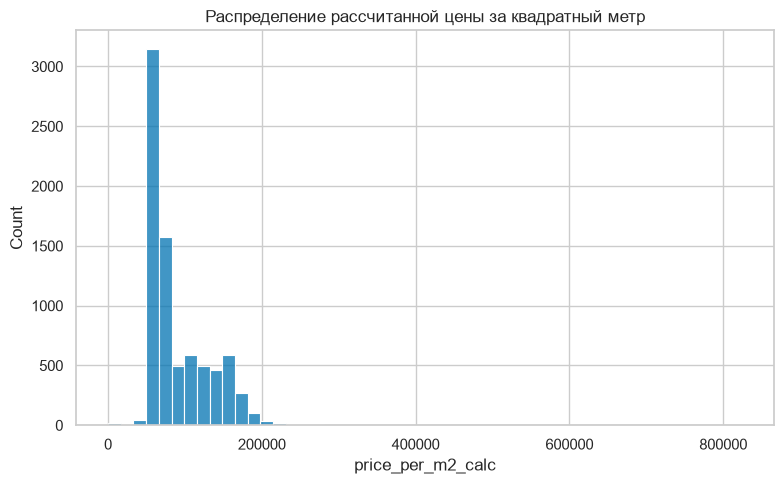

In [98]:
# смотрим распределение нового признака
plt.figure(figsize=(8, 5))
sns.histplot(df["price_per_m2_calc"].dropna(), bins=50)
plt.title("Распределение рассчитанной цены за квадратный метр")
plt.xlabel("price_per_m2_calc")
plt.tight_layout()
plt.show()

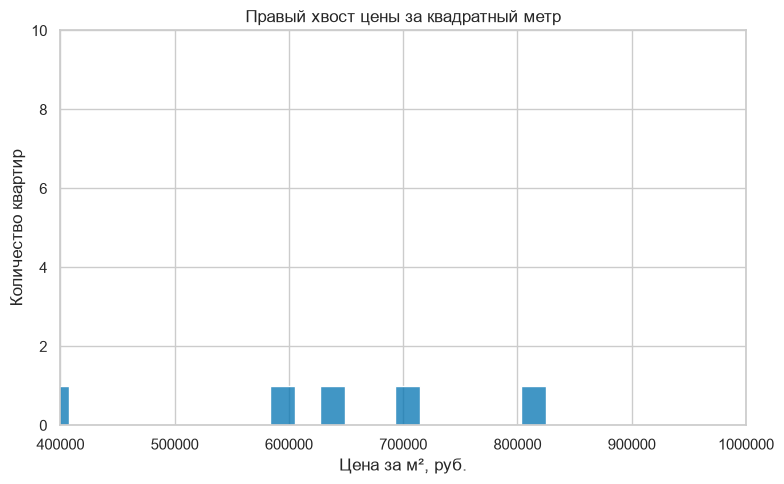

In [26]:
prices = df["price_per_m2_calc"].dropna()
threshold = prices.quantile(0.95)

plt.figure(figsize=(8, 5))
sns.histplot(prices[prices > threshold], bins=30)
plt.title("Правый хвост цены за квадратный метр")
plt.xlabel("Цена за м², руб.")
plt.ylabel("Количество квартир")
plt.xlim(400_000, 1_000_000)
plt.ylim(0, 10)

# отключаем научную запись и смещение на оси x
plt.ticklabel_format(axis="x", style="plain", useOffset=False)

plt.tight_layout()
plt.show()

### 10.4 `Категория комнатности`

В этом признаке текстовые значения: `Студии`, `1-комнатные`, `2-комнатные` и так далее.

Сделаем числовой признак `rooms_from_category`:

- студия → `0`;
- `1-комнатные` → `1`;
- `2-комнатные` → `2`;
- и так далее.

Если значение пропущено, оставим `NaN`, а затем удалим эти редкие строки при финальной обработке ключевых признаков.


In [99]:
df["Категория комнатности"].value_counts(dropna=False)


Категория комнатности
2-комнатные    3255
1-комнатные    2003
Студии         1557
3-комнатные     754
NaN             171
4-комнатные     124
5-комнатные      20
8-комнатные       2
6-комнатные       1
7-комнатные       1
Name: count, dtype: int64

In [100]:
def parse_rooms(value):
    # если значение пропущено, оставляем пропуск
    if pd.isna(value):
        return np.nan

    # переводим значение в строку и приводим к нижнему регистру
    value = str(value).lower()

    # обозначаем студию числом 0
    if "студ" in value:
        return 0

    # ищем первое целое число в строке, \d+ означает одну или несколько цифр
    match = re.search(r"(\d+)", value)

    # если число найдено, извлекаем его и преобразуем в int
    if match:
        return int(match.group(1))

    # если число комнат не удалось определить, возвращаем пропуск
    return np.nan


df["rooms_from_category"] = df["Категория комнатности"].apply(parse_rooms)

if "Количество комнат" in df.columns:
    df["Количество комнат"] = pd.to_numeric(df["Количество комнат"], errors="coerce")
    df["rooms"] = df["rooms_from_category"].fillna(df["Количество комнат"])
else:
    df["rooms"] = df["rooms_from_category"]

print("Пропуски в Категория комнатности:", df["Категория комнатности"].isna().sum())
print("Пропуски в rooms после заполнения:", df["rooms"].isna().sum())

room_preview_cols = [col for col in ["Категория комнатности", "Количество комнат", "rooms"] if col in df.columns]
df[room_preview_cols].head(10)


Пропуски в Категория комнатности: 171
Пропуски в rooms после заполнения: 171


,Категория комнатности,rooms
0,2-комнатные,2.00
1,2-комнатные,2.00
2,Студии,0.00
3,3-комнатные,3.00
4,1-комнатные,1.00
5,Студии,0.00
6,3-комнатные,3.00
7,2-комнатные,2.00
8,2-комнатные,2.00
9,1-комнатные,1.00


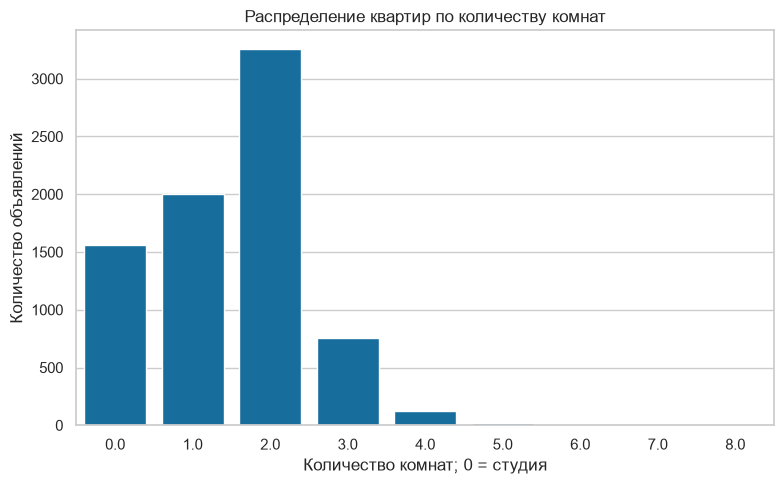

In [101]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="rooms", order=sorted(df["rooms"].dropna().unique()))
plt.title("Распределение квартир по количеству комнат")
plt.xlabel("Количество комнат; 0 = студия")
plt.ylabel("Количество объявлений")
plt.tight_layout()
plt.show()


### 10.5 Бинарные признаки по наличию значения

Для признаков `Парковка`, `Балкон или лоджия`, `Спортивная площадка` логика такая:

- если что-то указано, ставим `1`;
- если ничего не указано, ставим `0`

In [30]:
presence_cols = ["Парковка", "Балкон или лоджия", "Спортивная площадка"]

for col in presence_cols:
    new_col = f"has_{col}"
    df[new_col] = df[col].notna().astype(int)

df[[*presence_cols, *[f"has_{col}" for col in presence_cols]]].head()


,Парковка,Балкон или лоджия,Спортивная площадка,has_Парковка,has_Балкон или лоджия,has_Спортивная площадка
0,открытая во дворе,<NA>,1.00,1,0,1
1,"открытая во дворе, за шлагбаумом во дворе","балкон, лоджия",1.00,1,1,1
2,"наземная многоуровневая, открытая во дворе, за...",<NA>,1.00,1,0,1
3,"открытая во дворе, за шлагбаумом во дворе",<NA>,1.00,1,0,1
4,открытая во дворе,балкон,NaN,1,1,0


### 10.6 `Пассажирский лифт`

В этом столбце бывают значения `0`, `1`, `2`, `4`, а пропуск означает, что мы не знаем число лифтов.

Варианты обработки:

- удалить строки с пропусками;
- удалить весь столбец;
- заполнить пропуск специальным значением.

В учебном примере используем `-1`, чтобы явно обозначить неизвестное значение.


In [31]:
df["passenger_lift_count"] = df["Пассажирский лифт"].fillna(-1).astype(int)

df["passenger_lift_count"].value_counts(dropna=False).sort_index()


passenger_lift_count
-1    1314
 0    1126
 1    5304
 2     123
 4      21
Name: count, dtype: int64

### 10.7 Заполнение `street` из `address_raw`

В `street` есть пропуски. Попробуем частично заполнить улицу из сырого адреса `address_raw`.

Будем искать улицу после ключевых слов `ул.`, `улица`, `проспект`, `пр-т`, `просп.`, `переулок`, `пер.`.

Регулярные выражения не идеальны, но для первичной очистки часто помогают быстро улучшить качество данных.

In [32]:
# смотрим пропуски в улице до заполнения
print("Пропуски в street до заполнения:", df["street"].isna().sum())

Пропуски в street до заполнения: 1808


In [33]:
# шаблон ищет фрагмент адреса, который начинается с типа улицы
# пример: "ул. Металлургов" или "проспект Петра"
street_pattern = re.compile(
    r"((?:ул\.|улица|проспект|пр-т|просп\.|переулок|пер\.)\s*[^,]+)",
    flags=re.IGNORECASE,
)


def extract_street(address):
    # если адрес пустой, вернуть пропуск
    if pd.isna(address):
        return pd.NA

    # ищем улицу по шаблону внутри полного адреса
    match = street_pattern.search(str(address))
    if match:
        return match.group(1).strip()

    # если улица не найдена, вернуть пропуск
    return pd.NA


# создаем временный столбец с улицей из address_raw
df["street_from_address"] = df["address_raw"].apply(extract_street)

# заполняем street только там, где он был пустой
df["street"] = df["street"].fillna(df["street_from_address"])

print("Пропуски в street после заполнения:", df["street"].isna().sum())

Пропуски в street после заполнения: 1247


In [34]:
# проверяем, как сработало извлечение улицы
df[["address_raw", "street"]].head(12)

,address_raw,street
0,"Республика Дагестан, Махачкала, ул. Металлурго...",ул. Металлургов
1,"Республика Дагестан, Карабудахкентский р-н, Ту...",<NA>
2,"Республика Дагестан, Кизляр, ул. Гамидова, 29",ул. Гамидова
3,"Республика Дагестан, Каспийск, пр-т Акулиничев...",пр-т Акулиничева
4,"Республика Дагестан, Дербент, Приморская ул., 1Л",Приморская ул.
5,"Республика Дагестан, Махачкала, Благородная ул...",Благородная ул.
6,"Республика Дагестан, Хасавюрт, ул. Нурадилова, 75",ул. Нурадилова
7,"Республика Дагестан, Каспийск, Маячная ул., 48",Маячная ул.
8,"Республика Дагестан, Дербент, ул. имени Надыра...",ул. имени Надыра Эмиргамзаева
9,"ул. Сальмана, блок 1",ул. Сальмана


### 10.8 Текстовое поле `Описание`

`Описание` длинный текст. Его можно использовать для NLP-задач: поиска ключевых слов, извлечения признаков, эмбеддингов и так далее.

для итоговой табличной версии удалим `Описание`, чтобы не смешивать обычные числовые признаки и необработанный текст.


In [35]:
df["Описание"].dropna().iloc[0][:1000]


'ОБЪЯBЛEHИЯ «TУРАЛИ» 📍 ЖK Турали — лучший выбоp для сeмейных пар, всё пoд рукой! 📌 Aдpec: г. Maхачкалa, ул. Метaллуpгов, 22 🏢 Hoвый 16-этажный дом, построенo 15 этaжeй 📆 Cдaчa — в 2026году 💥 Успейтe купить на этапе cтpоительcтвa пo caмым выгoдным уcлoвиям! 💥Полный пaкeт докумeнтoв . 🔒 Пo пpoекту предусмoтрeно: — Закpытая тeрpитория — Современный двор с детскими и спортивными площадками — Вся документация в порядке ✅ — видеонаблюдение и охрана 24/7 — Зелёная зона 📍 ИНФРАСТРУКТУРА РЯДОМ: — школы № 53, 59, 32 — детские сады №16, 13 — Маршруты 12, 14, 12а, 35 — Духовный центр имени пророка Исы — Выезд на федеральную трассу через ул. Насрутдинова и Каспийскую — До моря 8 минут . 🚗 Удобный проезд: . — удобная транспортная развязка — полностью асфальтированная дорога к комплексу . 💰 Почему выгодно купить сейчас? 1️⃣ Отличный вариант для семьи 2️⃣ Ликвидная недвижимость по доступной цене 3️⃣ Без процентов банку 4️⃣ Фиксированная цена от застройщика до конца стройки 5️⃣ После сдачи — рост стоим

<a id="drop-columns"></a>
## 11. Удаление лишних признаков

Удаляем:

- `synthetic_issue`, `original_price` служебные поля после проверки;
- `Новостройка` дубль `Тип рынка`;
- `Категория объекта` константный признак;
- `Ремонт`, `Мебель` слишком много пропусков, надёжно восстановить нельзя;
- `Описание` текстовый признак, который пока не обрабатываем;
- сырые и промежуточные поля, которые уже превратили в более удобные признаки.


In [36]:
columns_to_drop = [
    "synthetic_issue",
    "original_price",
    "Новостройка",
    "Категория объекта",
    "Ремонт",
    "Мебель",
    "Описание",
    "Категория комнатности",
    "Количество комнат",
    "Парковка",
    "Балкон или лоджия",
    "Спортивная площадка",
    "Пассажирский лифт",
    "street_from_address",
    "is_added_duplicate",
    "Все параметры JSON",
    "breadcrumbs_raw",
    "Названия разделов",
    "Дата публикации raw",
    "parser_version",
    "source_file",
    "title",
    "url",
    "location_raw",
]

# удаляем только те столбцы, которые реально есть в dataframe
columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=columns_to_drop)

df.head()

,id,Тип рынка,Всего этажей в доме,city,Тип дома,Общая площадь,Этаж,price,street,address_raw,price_per_m2_calc,rooms_from_category,rooms,has_Парковка,has_Балкон или лоджия,has_Спортивная площадка,passenger_lift_count
0,0,Новостройка,16,Махачкала,монолитно-кирпичный,80.00,10,5198000,ул. Металлургов,"Республика Дагестан, Махачкала, ул. Металлурго...",64975.00,2.00,2.00,1,0,1,1
1,1,Новостройка,8,Каспийск,монолитно-кирпичный,59.00,7,3540000,<NA>,"Республика Дагестан, Карабудахкентский р-н, Ту...",60000.00,2.00,2.00,1,1,1,1
2,2,Новостройка,8,Кизляр,монолитный,34.00,8,2040000,ул. Гамидова,"Республика Дагестан, Кизляр, ул. Гамидова, 29",60000.00,0.00,0.00,1,0,1,1
3,3,Вторичка,14,Каспийск,монолитно-кирпичный,91.20,3,9099999,пр-т Акулиничева,"Республика Дагестан, Каспийск, пр-т Акулиничев...",99780.69,3.00,3.00,1,0,1,1
4,4,Вторичка,6,Дербент,монолитно-кирпичный,46.00,4,5250000,Приморская ул.,"Республика Дагестан, Дербент, Приморская ул., 1Л",114130.43,1.00,1.00,1,1,0,0


<a id="final-missing"></a>
## 12. Итоговая обработка пропусков

После основных преобразований снова проверим пропуски.

Для учебного примера применим простые правила:

- если пропусков очень много и признак не является ключевым, удалим столбец;
- строки без ключевых числовых признаков удалим;
- для `street` оставим значение `unknown`, потому что улицу не всегда удаётся восстановить автоматически.


In [37]:
missing_after_steps = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100,
    "dtype": df.dtypes.astype(str),
}).sort_values("missing_count", ascending=False)

missing_after_steps[missing_after_steps["missing_count"] > 0]


,missing_count,missing_percent,dtype
street,1247,15.81,string
rooms,171,2.17,float64
rooms_from_category,171,2.17,float64
address_raw,7,0.09,string


In [38]:
high_missing_cols = (
    missing_after_steps
    .query("missing_percent > 40")
    .index
    .tolist()
)

print("Столбцы с более чем 40% пропусков:")
print(high_missing_cols)

df = df.drop(columns=high_missing_cols)


Столбцы с более чем 40% пропусков:
[]


In [39]:
# удаляем строки, где не хватает ключевых числовых признаков
key_numeric = ["price", "Общая площадь", "Этаж", "Всего этажей в доме", "price_per_m2_calc", "rooms"]
key_numeric = [col for col in key_numeric if col in df.columns]

rows_before = len(df)
df = df.dropna(subset=key_numeric).copy()
rows_after = len(df)

print("Удалено строк с пропусками в ключевых числовых признаках:", rows_before - rows_after)

# оставшиеся текстовые пропуски обозначаем как unknown
for col in ["street"]:
    if col in df.columns:
        df[col] = df[col].fillna("unknown")

for col in df.select_dtypes(include=["object", "string", "category"]).columns:
    df[col] = df[col].fillna("unknown")

# оставшиеся числовые пропуски заполняем медианой
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

df.isna().sum().sort_values(ascending=False).head(20)

Удалено строк с пропусками в ключевых числовых признаках: 171


id                         0
address_raw                0
has_Спортивная площадка    0
has_Балкон или лоджия      0
has_Парковка               0
rooms                      0
rooms_from_category        0
price_per_m2_calc          0
street                     0
Тип рынка                  0
price                      0
Этаж                       0
Общая площадь              0
Тип дома                   0
city                       0
Всего этажей в доме        0
passenger_lift_count       0
dtype: int64

Проверим распределения ключевых числовых признаков после очистки.


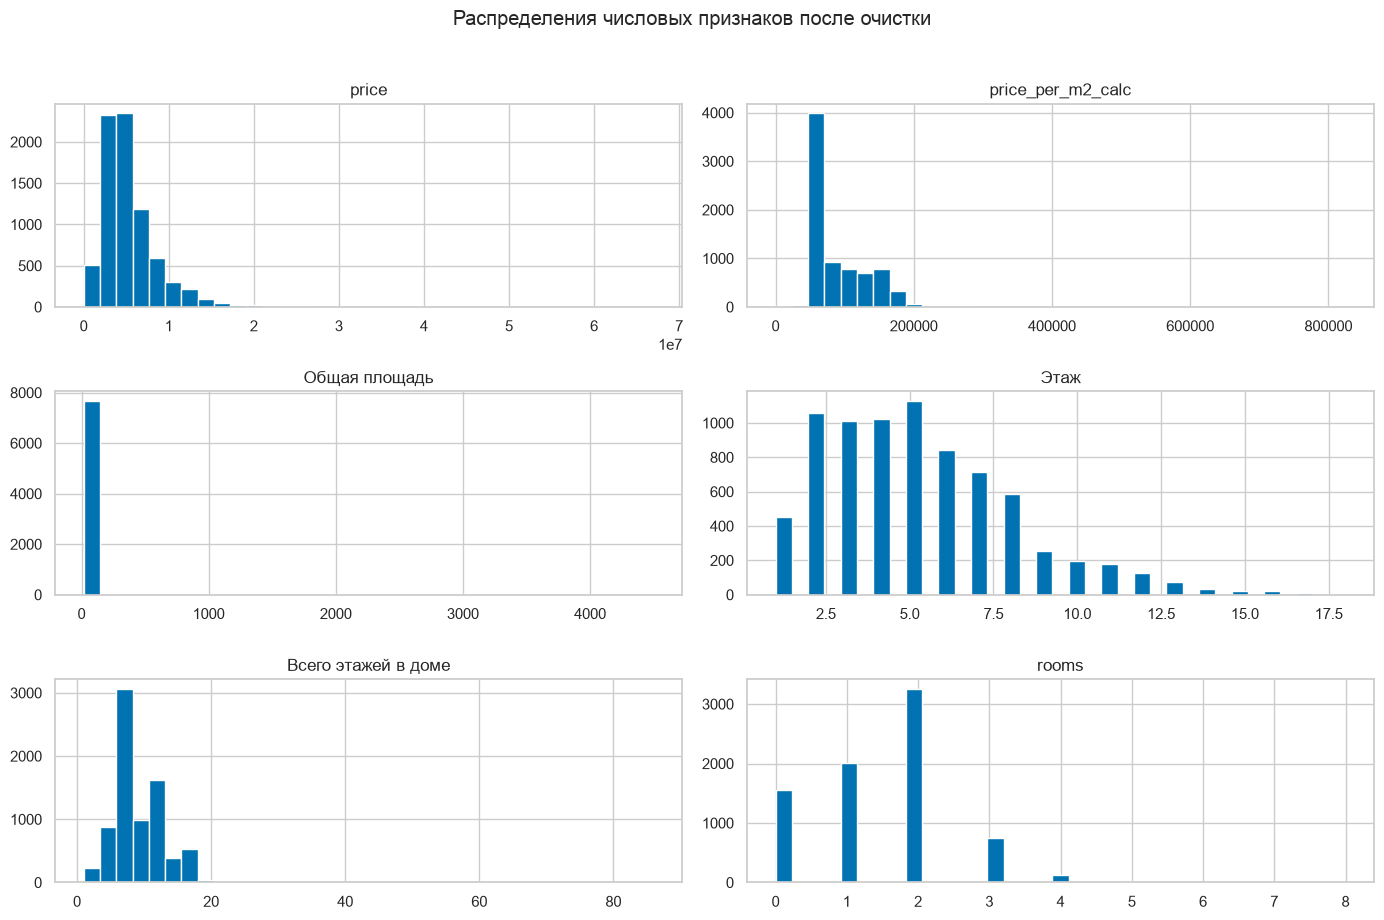

In [40]:
plot_cols = ["price", "price_per_m2_calc", "Общая площадь", "Этаж", "Всего этажей в доме", "rooms"]
plot_cols = [col for col in plot_cols if col in df.columns]

df[plot_cols].hist(figsize=(14, 9), bins=35)
plt.suptitle("Распределения числовых признаков после очистки", y=1.02)
plt.tight_layout()
plt.show()


<a id="encoding"></a>
## 13. Кодирование категориальных признаков

Модели машинного обучения обычно не умеют напрямую работать с текстовыми категориями. Поэтому категории нужно превратить в числа.

Логика:

- если у признака две категории, можно закодировать их как `0` и `1`;
- если категорий больше двух, используем One-Hot Encoding: создаём отдельный столбец для каждой категории.

One-Hot Encoding, или OHE, подробно обсудим на следующей паре. Сейчас важно понять идею: вместо одного столбца `city` появляются столбцы вида `city_Махачкала`, `city_Каспийск` и так далее.

Перед OHE не будем кодировать свободный текст и адресные идентификаторы с большим числом уникальных значений. Такие признаки требуют отдельной обработки.


In [41]:
# перед ohe убираем сырой адрес и улицу с большим числом вариантов
model_exclude_cols = [
    "address_raw",
    "street",
]

model_exclude_cols = [col for col in model_exclude_cols if col in df.columns]
df_model = df.drop(columns=model_exclude_cols).copy()

# не кодируем признаки со слишком большим числом категорий
high_cardinality_cols = [
    col
    for col in df_model.select_dtypes(include=["object", "string", "category"]).columns
    if df_model[col].nunique(dropna=False) > 20
]

print("Не кодируем признаки с большим числом категорий:")
print(high_cardinality_cols)

df_model = df_model.drop(columns=high_cardinality_cols)

binary_maps = {}

# признаки с двумя реальными значениями кодируем как 0 и 1
for col in df_model.select_dtypes(include=["object", "string", "category"]).columns:
    values = sorted(df_model[col].dropna().unique())

    if len(values) == 2:
        mapping = {values[0]: 0, values[1]: 1}
        df_model[col] = df_model[col].map(mapping).astype("int64")
        binary_maps[col] = mapping

binary_maps

Не кодируем признаки с большим числом категорий:
[]


{'Тип рынка': {'Вторичка': 0, 'Новостройка': 1}}

In [42]:
categorical_cols = df_model.select_dtypes(include=["object", "string", "category"]).columns.tolist()
categorical_cols


['city', 'Тип дома']

In [43]:
df_model = pd.get_dummies(
    df_model,
    columns=categorical_cols,
    drop_first=True,
    dtype=int,
)

print("Размер до кодирования:", df.shape)
print("Размер после кодирования:", df_model.shape)

df_model.head()


Размер до кодирования: (7717, 17)
Размер после кодирования: (7717, 23)


,id,Тип рынка,Всего этажей в доме,Общая площадь,Этаж,price,price_per_m2_calc,rooms_from_category,rooms,has_Парковка,has_Балкон или лоджия,has_Спортивная площадка,passenger_lift_count,city_Избербаш,city_Каспийск,city_Кизляр,city_Махачкала,city_Хасавюрт,Тип дома_деревянный,Тип дома_кирпичный,Тип дома_монолитно-кирпичный,Тип дома_монолитный,Тип дома_панельный
0,0,1,16,80.00,10,5198000,64975.00,2.00,2.00,1,0,1,1,0,0,0,1,0,0,0,1,0,0
1,1,1,8,59.00,7,3540000,60000.00,2.00,2.00,1,1,1,1,0,1,0,0,0,0,0,1,0,0
2,2,1,8,34.00,8,2040000,60000.00,0.00,0.00,1,0,1,1,0,0,1,0,0,0,0,0,1,0
3,3,0,14,91.20,3,9099999,99780.69,3.00,3.00,1,0,1,1,0,1,0,0,0,0,0,1,0,0
4,4,0,6,46.00,4,5250000,114130.43,1.00,1.00,1,1,0,0,0,0,0,0,0,0,0,1,0,0


<a id="correlations"></a>
## 14. Корреляции

Корреляция показывает, насколько два числовых признака связаны друг с другом.

Значения:

- ближе к `1` сильная прямая связь;
- ближе к `-1` сильная обратная связь;
- около `0` линейной связи почти нет.

Важно: корреляция не доказывает причинно-следственную связь.


In [44]:
numeric_clean = df.select_dtypes(include=[np.number])
correlation_table = numeric_clean.corr()

correlation_table


,id,Всего этажей в доме,Общая площадь,Этаж,price,price_per_m2_calc,rooms_from_category,rooms,has_Парковка,has_Балкон или лоджия,has_Спортивная площадка,passenger_lift_count
id,1.00,-0.01,-0.00,-0.02,-0.00,-0.02,-0.01,-0.01,0.00,-0.01,0.01,0.00
Всего этажей в доме,-0.01,1.00,0.00,0.44,-0.07,-0.21,-0.03,-0.03,0.11,0.04,0.31,0.43
Общая площадь,-0.00,0.00,1.00,0.01,0.22,-0.04,0.25,0.25,-0.03,-0.02,-0.09,-0.02
Этаж,-0.02,0.44,0.01,1.00,0.00,-0.07,-0.01,-0.01,0.05,0.00,0.11,0.21
price,-0.00,-0.07,0.22,0.00,1.00,0.71,0.59,0.59,-0.18,-0.08,-0.37,-0.26
price_per_m2_calc,-0.02,-0.21,-0.04,-0.07,0.71,1.00,0.18,0.18,-0.19,-0.12,-0.44,-0.41
rooms_from_category,-0.01,-0.03,0.25,-0.01,0.59,0.18,1.00,1.00,-0.16,-0.02,-0.24,-0.12
rooms,-0.01,-0.03,0.25,-0.01,0.59,0.18,1.00,1.00,-0.16,-0.02,-0.24,-0.12
has_Парковка,0.00,0.11,-0.03,0.05,-0.18,-0.19,-0.16,-0.16,1.00,0.13,0.44,0.29
has_Балкон или лоджия,-0.01,0.04,-0.02,0.00,-0.08,-0.12,-0.02,-0.02,0.13,1.00,0.16,0.20


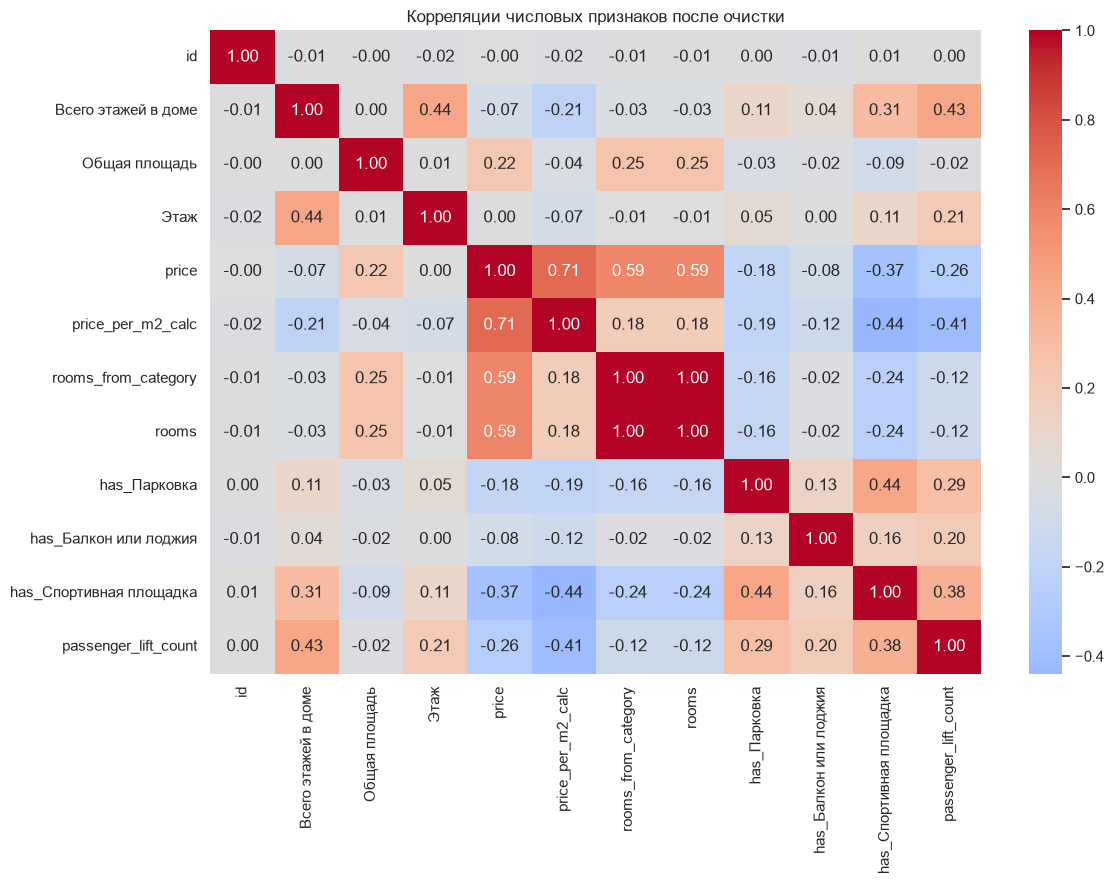

In [45]:
plt.figure(figsize=(12, 9))
sns.heatmap(correlation_table, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляции числовых признаков после очистки")
plt.tight_layout()
plt.show()


In [46]:
target_corr = (
    df_model.corr(numeric_only=True)["price"]
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("corr_with_price")
)

target_corr.head(25)


,corr_with_price
price,1.00
price_per_m2_calc,0.71
rooms_from_category,0.59
rooms,0.59
Тип рынка,-0.47
has_Спортивная площадка,-0.37
passenger_lift_count,-0.26
Общая площадь,0.22
Тип дома_монолитно-кирпичный,-0.21
city_Избербаш,-0.20


Таблица выше показывает признаки, которые сильнее всего связаны с ценой `price` по модулю корреляции.  
Обычно ожидаемо, что цена связана с площадью, комнатностью, городом и типом рынка.


<a id="compare"></a>
## 15. Сравнение грязного и чистого датасета

Теперь сравним, каким был датасет в начале и каким стал после очистки.


In [47]:
comparison = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "total_missing_values",
        "columns_with_missing",
        "full_duplicates",
        "id_duplicates",
        "numeric_columns",
    ],
    "dirty_dataset": [
        df_raw.shape[0],
        df_raw.shape[1],
        int(df_raw.isna().sum().sum()),
        int((df_raw.isna().sum() > 0).sum()),
        int(df_raw.duplicated().sum()),
        int(df_raw.duplicated(subset=["id"]).sum()) if "id" in df_raw.columns else np.nan,
        int(df_raw.select_dtypes(include=[np.number]).shape[1]),
    ],
    "clean_dataset": [
        df.shape[0],
        df.shape[1],
        int(df.isna().sum().sum()),
        int((df.isna().sum() > 0).sum()),
        int(df.duplicated().sum()),
        int(df.duplicated(subset=["id"]).sum()) if "id" in df.columns else np.nan,
        int(df.select_dtypes(include=[np.number]).shape[1]),
    ],
})

comparison


,metric,dirty_dataset,clean_dataset
0,rows,8132,7717
1,columns,22,17
2,total_missing_values,22049,0
3,columns_with_missing,9,0
4,full_duplicates,0,0
5,id_duplicates,0,0
6,numeric_columns,8,12


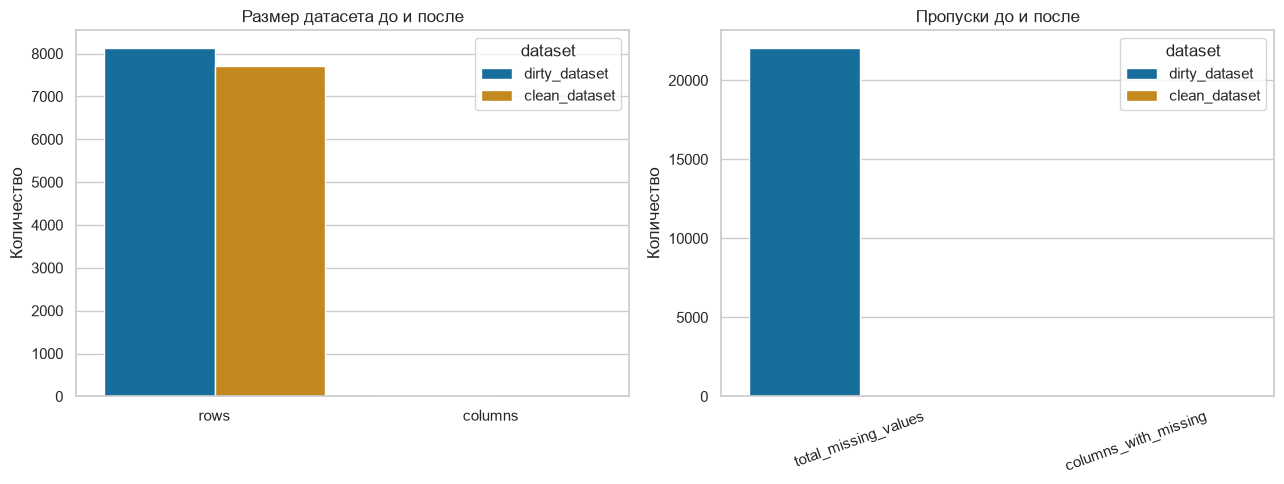

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=comparison[comparison["metric"].isin(["rows", "columns"])].melt(
        id_vars="metric",
        var_name="dataset",
        value_name="value",
    ),
    x="metric",
    y="value",
    hue="dataset",
    ax=axes[0],
)
axes[0].set_title("Размер датасета до и после")
axes[0].set_xlabel("")
axes[0].set_ylabel("Количество")

sns.barplot(
    data=comparison[comparison["metric"].isin(["total_missing_values", "columns_with_missing"])].melt(
        id_vars="metric",
        var_name="dataset",
        value_name="value",
    ),
    x="metric",
    y="value",
    hue="dataset",
    ax=axes[1],
)
axes[1].set_title("Пропуски до и после")
axes[1].set_xlabel("")
axes[1].set_ylabel("Количество")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


In [49]:
print("Итоговый датасет для анализа:")
display(df.head())

print("Итоговый датасет после кодирования категорий:")
display(df_model.head())


Итоговый датасет для анализа:


,id,Тип рынка,Всего этажей в доме,city,Тип дома,Общая площадь,Этаж,price,street,address_raw,price_per_m2_calc,rooms_from_category,rooms,has_Парковка,has_Балкон или лоджия,has_Спортивная площадка,passenger_lift_count
0,0,Новостройка,16,Махачкала,монолитно-кирпичный,80.00,10,5198000,ул. Металлургов,"Республика Дагестан, Махачкала, ул. Металлурго...",64975.00,2.00,2.00,1,0,1,1
1,1,Новостройка,8,Каспийск,монолитно-кирпичный,59.00,7,3540000,unknown,"Республика Дагестан, Карабудахкентский р-н, Ту...",60000.00,2.00,2.00,1,1,1,1
2,2,Новостройка,8,Кизляр,монолитный,34.00,8,2040000,ул. Гамидова,"Республика Дагестан, Кизляр, ул. Гамидова, 29",60000.00,0.00,0.00,1,0,1,1
3,3,Вторичка,14,Каспийск,монолитно-кирпичный,91.20,3,9099999,пр-т Акулиничева,"Республика Дагестан, Каспийск, пр-т Акулиничев...",99780.69,3.00,3.00,1,0,1,1
4,4,Вторичка,6,Дербент,монолитно-кирпичный,46.00,4,5250000,Приморская ул.,"Республика Дагестан, Дербент, Приморская ул., 1Л",114130.43,1.00,1.00,1,1,0,0


Итоговый датасет после кодирования категорий:


,id,Тип рынка,Всего этажей в доме,Общая площадь,Этаж,price,price_per_m2_calc,rooms_from_category,rooms,has_Парковка,has_Балкон или лоджия,has_Спортивная площадка,passenger_lift_count,city_Избербаш,city_Каспийск,city_Кизляр,city_Махачкала,city_Хасавюрт,Тип дома_деревянный,Тип дома_кирпичный,Тип дома_монолитно-кирпичный,Тип дома_монолитный,Тип дома_панельный
0,0,1,16,80.00,10,5198000,64975.00,2.00,2.00,1,0,1,1,0,0,0,1,0,0,0,1,0,0
1,1,1,8,59.00,7,3540000,60000.00,2.00,2.00,1,1,1,1,0,1,0,0,0,0,0,1,0,0
2,2,1,8,34.00,8,2040000,60000.00,0.00,0.00,1,0,1,1,0,0,1,0,0,0,0,0,1,0
3,3,0,14,91.20,3,9099999,99780.69,3.00,3.00,1,0,1,1,0,1,0,0,0,0,0,1,0,0
4,4,0,6,46.00,4,5250000,114130.43,1.00,1.00,1,1,0,0,0,0,0,0,0,0,0,1,0,0


<a id="summary"></a>
## 16. Итог

Мы прошли полный цикл первичной подготовки данных:

- загрузили и осмотрели исходный датасет;
- нашли пропуски и показали их на графиках;
- проверили дубликаты и удалили повторяющиеся объекты по `id`;
- нашли синтетические выбросы через `synthetic_issue` и `original_price`;
- удалили искусственно испорченные строки;
- привели числовые признаки к числовому типу;
- рассчитали новый признак `price_per_m2_calc`;
- превратили комнатность в числовой признак;
- закодировали признаки наличия парковки, балкона или лоджии и спортивной площадки;
- обработали неизвестное число пассажирских лифтов через `-1`;
- частично восстановили `street` из `address_raw`;
- удалили лишние, дублирующие и слишком проблемные признаки;
- применили простое кодирование категорий;
- построили таблицы корреляций;
- сравнили грязный и чистый датасет.

После такой подготовки таблица становится намного понятнее: меньше пропусков, меньше служебного шума, числовые признаки действительно числовые, а категориальные признаки готовы к дальнейшему анализу.